In [ ]:
print("Sales Forecasting Project Started!")

Sales Forecasting Project Started!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ==========================================
# STEP 3: CREATE SALES DATASET
# ==========================================

np.random.seed(42)

n = 10000

# Generate dates
dates = pd.date_range(
    start="2022-01-01",
    end="2025-12-31",
    periods=n
)

# Product list
products = [
    "Laptop",
    "Mobile",
    "Tablet",
    "Headphones",
    "Keyboard",
    "Mouse",
    "Monitor",
    "Printer"
]

# Category list
categories = [
    "Electronics",
    "Accessories",
    "Office"
]

# Region list
regions = [
    "North",
    "South",
    "East",
    "West"
]

# Create DataFrame
df = pd.DataFrame({
    "Order Date": dates,
    "Product": np.random.choice(products, n),
    "Category": np.random.choice(categories, n),
    "Region": np.random.choice(regions, n),
    "Quantity": np.random.randint(1, 10, n),
    "Sales": np.random.randint(500, 50000, n)
})

print("Dataset created successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset created successfully!
Dataset Shape: (10000, 6)


,Order Date,Product,Category,Region,Quantity,Sales
0,2022-01-01 00:00:00.000000000,Monitor,Office,North,1,47982
1,2022-01-01 03:30:15.661566156,Headphones,Office,North,2,16487
2,2022-01-01 07:00:31.323132313,Keyboard,Office,East,1,37685
3,2022-01-01 10:30:46.984698469,Monitor,Accessories,North,7,4199
4,2022-01-01 14:01:02.646264626,Tablet,Office,North,6,46936


In [ ]:
print("Number of Rows:", len(df))
print("Number of Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 10000
Number of Columns: 6

Columns:
['Order Date', 'Product', 'Category', 'Region', 'Quantity', 'Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  10000 non-null  datetime64[ns]
 1   Product     10000 non-null  object        
 2   Category    10000 non-null  object        
 3   Region      10000 non-null  object        
 4   Quantity    10000 non-null  int64         
 5   Sales       10000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 468.9+ KB


In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Order Date    0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
dtype: int64

Duplicate Rows:
0


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate Revenue
df["Revenue"] = df["Sales"] * df["Quantity"]

print("Data cleaning completed!")
print("Final Dataset Shape:", df.shape)

df.head()

Data cleaning completed!
Final Dataset Shape: (10000, 7)


,Order Date,Product,Category,Region,Quantity,Sales,Revenue
0,2022-01-01 00:00:00.000000000,Monitor,Office,North,1,47982,47982
1,2022-01-01 03:30:15.661566156,Headphones,Office,North,2,16487,32974
2,2022-01-01 07:00:31.323132313,Keyboard,Office,East,1,37685,37685
3,2022-01-01 10:30:46.984698469,Monitor,Accessories,North,7,4199,29393
4,2022-01-01 14:01:02.646264626,Tablet,Office,North,6,46936,281616


In [ ]:
print("Revenue Statistics:")
print(df["Revenue"].describe())

Revenue Statistics:
count     10000.000000
mean     126772.851600
std      103119.082087
min         513.000000
25%       41681.250000
50%       97101.000000
75%      189538.500000
max      449964.000000
Name: Revenue, dtype: float64


In [ ]:
# Create Month column
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

# Calculate monthly revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

print("Monthly Revenue:")
print(monthly_revenue.head(10))

Monthly Revenue:
     Month   Revenue
0  2022-01  23852801
1  2022-02  24684347
2  2022-03  25936331
3  2022-04  24517427
4  2022-05  26045771
5  2022-06  27182434
6  2022-07  25643102
7  2022-08  25622274
8  2022-09  27582242
9  2022-10  29044254


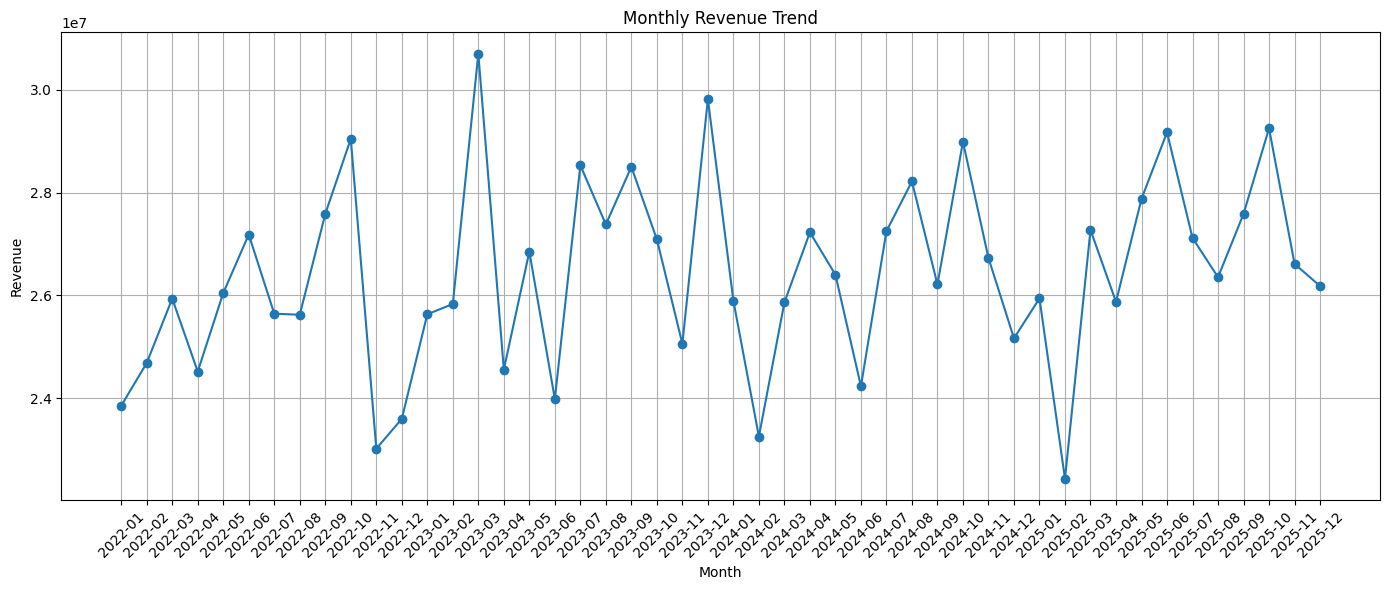

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
Month       2023-03
Revenue    30701967
Name: 14, dtype: object

Lowest Revenue Month:
Month       2025-02
Revenue    22431229
Name: 37, dtype: object


In [ ]:
# Product-wise revenue
product_revenue = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Product-wise Revenue:")
print(product_revenue)

Product-wise Revenue:
Product
Laptop        163297640
Keyboard      162541680
Headphones    160380864
Tablet        158586766
Mouse         158250872
Printer       156953339
Monitor       154098627
Mobile        153618728
Name: Revenue, dtype: int64


In [ ]:
# Top 5 products
top_products = product_revenue.head(5)

print("Top 5 Products:")
print(top_products)

Top 5 Products:
Product
Laptop        163297640
Keyboard      162541680
Headphones    160380864
Tablet        158586766
Mouse         158250872
Name: Revenue, dtype: int64


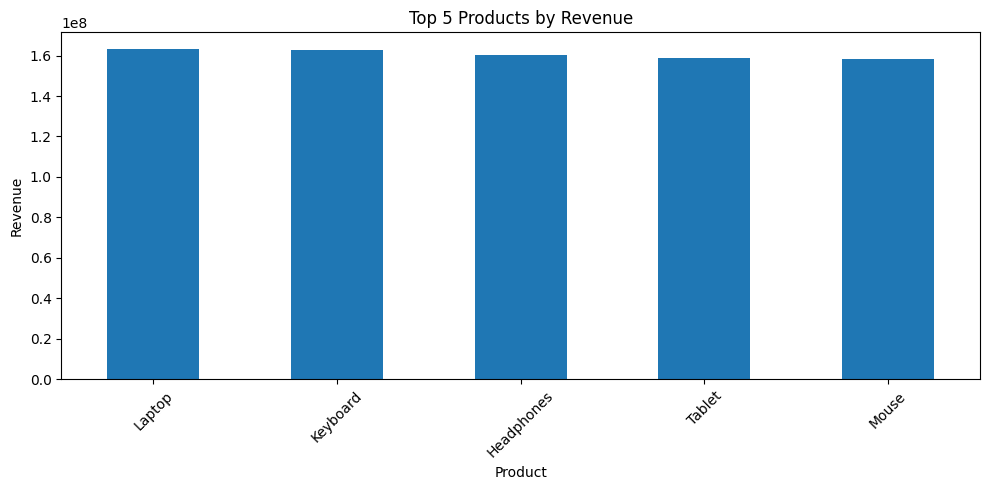

In [ ]:
plt.figure(figsize=(10, 5))

top_products.plot(kind="bar")

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Category-wise revenue
category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Category-wise Revenue:")
print(category_revenue)

Category-wise Revenue:
Category
Accessories    434084257
Electronics    422572260
Office         411071999
Name: Revenue, dtype: int64


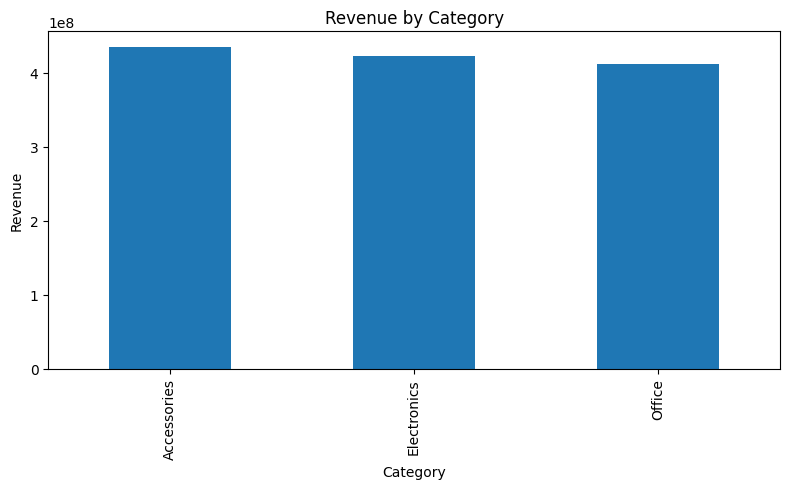

In [ ]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [ ]:
# Create month number and month name
df["Month_Number"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

# Calculate seasonal revenue
monthly_seasonality = (
    df.groupby(["Month_Number", "Month_Name"])["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

print(monthly_seasonality)

    Month_Number Month_Name    Revenue
0              1    January  101322296
1              2   February   96199912
2              3      March  109773987
3              4      April  102171556
4              5        May  107174510
5              6       June  104565548
6              7       July  108534813
7              8     August  107568845
8              9  September  109876680
9             10    October  114368194
10            11   November  101412996
11            12   December  104759179


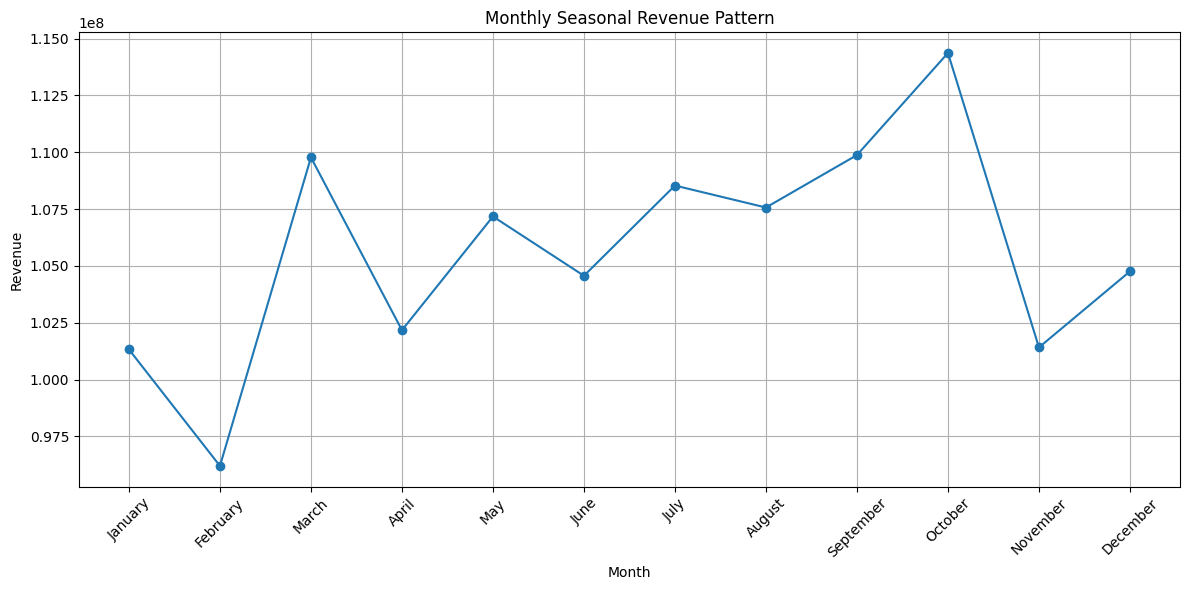

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["Revenue"],
    marker="o"
)

plt.title("Monthly Seasonal Revenue Pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
highest_season = monthly_seasonality.loc[
    monthly_seasonality["Revenue"].idxmax()
]

lowest_season = monthly_seasonality.loc[
    monthly_seasonality["Revenue"].idxmin()
]

print("Highest Seasonal Revenue Month:")
print(highest_season)

print("\nLowest Seasonal Revenue Month:")
print(lowest_season)

Highest Seasonal Revenue Month:
Month_Number           10
Month_Name        October
Revenue         114368194
Name: 9, dtype: object

Lowest Seasonal Revenue Month:
Month_Number           2
Month_Name      February
Revenue         96199912
Name: 1, dtype: object


In [ ]:
# Convert Month to datetime
monthly_revenue["Month"] = pd.to_datetime(
    monthly_revenue["Month"]
)

# Sort by date
monthly_revenue = monthly_revenue.sort_values("Month")

print(monthly_revenue.head())
print(monthly_revenue.tail())

       Month   Revenue
0 2022-01-01  23852801
1 2022-02-01  24684347
2 2022-03-01  25936331
3 2022-04-01  24517427
4 2022-05-01  26045771
        Month   Revenue
43 2025-08-01  26352013
44 2025-09-01  27583809
45 2025-10-01  29248203
46 2025-11-01  26611804
47 2025-12-01  26180045


In [ ]:
# Create time-based features
monthly_revenue["Year"] = monthly_revenue["Month"].dt.year
monthly_revenue["Month_Number"] = monthly_revenue["Month"].dt.month

# Sequential time index
monthly_revenue["Time_Index"] = range(
    1,
    len(monthly_revenue) + 1
)

print(monthly_revenue.head())

       Month   Revenue  Year  Month_Number  Time_Index
0 2022-01-01  23852801  2022             1           1
1 2022-02-01  24684347  2022             2           2
2 2022-03-01  25936331  2022             3           3
3 2022-04-01  24517427  2022             4           4
4 2022-05-01  26045771  2022             5           5


In [ ]:
# Use 80% data for training and 20% for testing
train_size = int(len(monthly_revenue) * 0.8)

train = monthly_revenue.iloc[:train_size]
test = monthly_revenue.iloc[train_size:]

print("Total Months:", len(monthly_revenue))
print("Training Months:", len(train))
print("Testing Months:", len(test))

Total Months: 48
Training Months: 38
Testing Months: 10


In [ ]:
# Features
X_train = train[["Time_Index", "Month_Number"]]
X_test = test[["Time_Index", "Month_Number"]]

# Target
y_train = train["Revenue"]
y_test = test["Revenue"]

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (38, 2)
X_test Shape: (10, 2)
y_train Shape: (38,)
y_test Shape: (10,)


In [ ]:
# ==========================================
# STEP 9: TRAIN FORECASTING MODEL
# ==========================================

from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [ ]:
# ==========================================
# STEP 9.1: GENERATE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nActual Revenue:")
print(y_test.values)

print("\nPredicted Revenue:")
print(y_pred)

Predictions generated successfully!

Actual Revenue:
[27273152 25872468 27877330 29170120 27116311 26352013 27583809 29248203
 26611804 26180045]

Predicted Revenue:
[25895853.25308271 26047977.93256713 26200102.61205156 26352227.29153598
 26504351.97102041 26656476.65050483 26808601.32998926 26960726.00947368
 27112850.68895811 27264975.36844254]


In [ ]:
comparison = pd.DataFrame({
    "Month": test["Month"].values,
    "Actual Revenue": y_test.values,
    "Predicted Revenue": y_pred
})

print(comparison)

       Month  Actual Revenue  Predicted Revenue
0 2025-03-01        27273152       2.589585e+07
1 2025-04-01        25872468       2.604798e+07
2 2025-05-01        27877330       2.620010e+07
3 2025-06-01        29170120       2.635223e+07
4 2025-07-01        27116311       2.650435e+07
5 2025-08-01        26352013       2.665648e+07
6 2025-09-01        27583809       2.680860e+07
7 2025-10-01        29248203       2.696073e+07
8 2025-11-01        26611804       2.711285e+07
9 2025-12-01        26180045       2.726498e+07


In [ ]:
# ==========================================
# STEP 10: MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE
mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("MODEL EVALUATION")
print("----------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MODEL EVALUATION
----------------
MAE  : 1161301.32
RMSE : 1428641.95
MAPE : 4.15 %


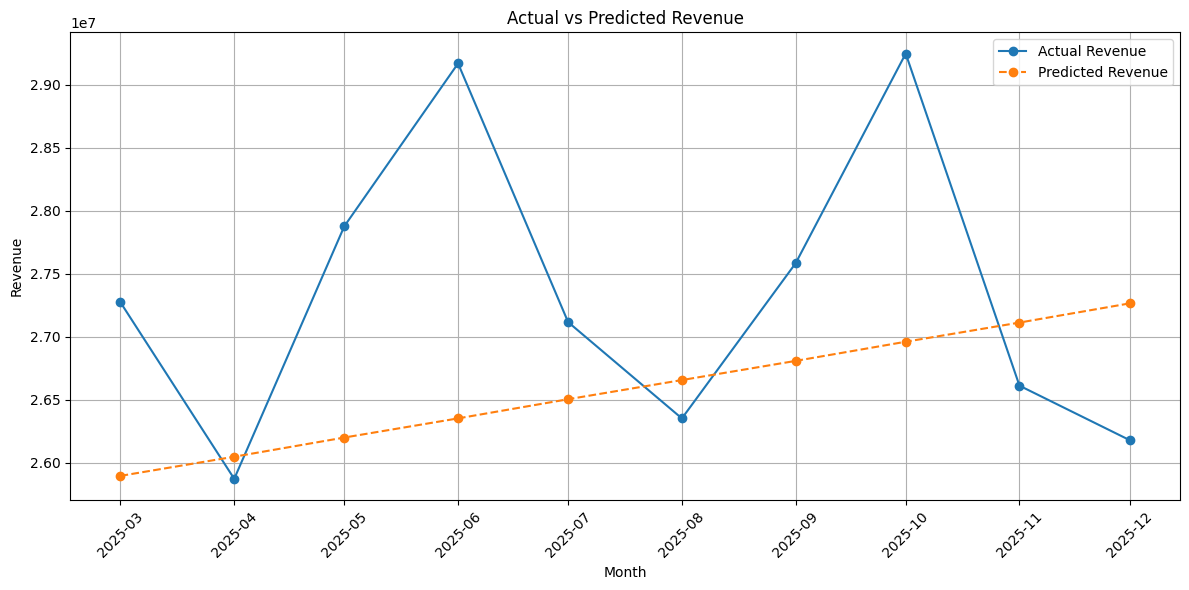

In [ ]:
# Actual vs Predicted Revenue

plt.figure(figsize=(12, 6))

plt.plot(
    test["Month"],
    y_test.values,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    test["Month"],
    y_pred,
    marker="o",
    linestyle="--",
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 11: FUTURE 6-MONTH FORECAST
# ==========================================

# Find the last month in our dataset
last_month = monthly_revenue["Month"].max()

# Create next 6 months
future_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

# Create future dataframe
future_df = pd.DataFrame({
    "Month": future_months
})

# Create required features
future_df["Month_Number"] = future_df["Month"].dt.month

future_df["Time_Index"] = range(
    len(monthly_revenue) + 1,
    len(monthly_revenue) + 7
)

print("Future Months:")
print(future_df)

Future Months:
       Month  Month_Number  Time_Index
0 2026-01-01             1          49
1 2026-02-01             2          50
2 2026-03-01             3          51
3 2026-04-01             4          52
4 2026-05-01             5          53
5 2026-06-01             6          54


In [ ]:
# Generate future predictions

future_X = future_df[
    ["Time_Index", "Month_Number"]
]

future_predictions = model.predict(future_X)

future_df["Predicted_Revenue"] = future_predictions

print("6-Month Revenue Forecast:")
print(future_df)

6-Month Revenue Forecast:
       Month  Month_Number  Time_Index  Predicted_Revenue
0 2026-01-01             1          49       2.570703e+07
1 2026-02-01             2          50       2.585915e+07
2 2026-03-01             3          51       2.601128e+07
3 2026-04-01             4          52       2.616340e+07
4 2026-05-01             5          53       2.631553e+07
5 2026-06-01             6          54       2.646765e+07


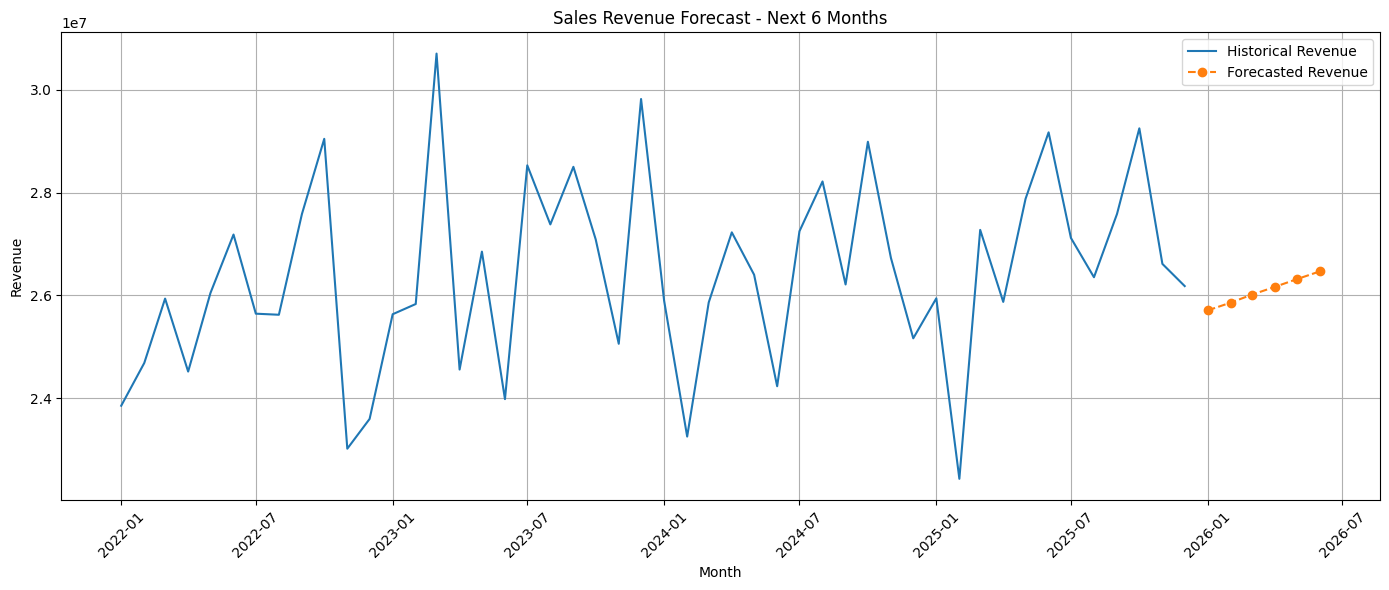

In [ ]:
# ==========================================
# FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 6))

# Historical revenue
plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    label="Historical Revenue"
)

# Future forecast
plt.plot(
    future_df["Month"],
    future_df["Predicted_Revenue"],
    marker="o",
    linestyle="--",
    label="Forecasted Revenue"
)

plt.title("Sales Revenue Forecast - Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
forecast_table = future_df[
    ["Month", "Predicted_Revenue"]
].copy()

forecast_table["Predicted_Revenue"] = forecast_table[
    "Predicted_Revenue"
].round(2)

print(forecast_table)

       Month  Predicted_Revenue
0 2026-01-01        25707027.48
1 2026-02-01        25859152.16
2 2026-03-01        26011276.84
3 2026-04-01        26163401.52
4 2026-05-01        26315526.20
5 2026-06-01        26467650.88


In [ ]:
# ==========================================
# STEP 12: BUSINESS INSIGHTS
# ==========================================

# Highest revenue month
highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

# Lowest revenue month
lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

# Top product
top_product = product_revenue.idxmax()
top_product_revenue = product_revenue.max()

# Top category
top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print("BUSINESS INSIGHTS")
print("=================")

print(
    f"1. Highest monthly revenue was generated in "
    f"{highest_month['Month'].strftime('%B %Y')} "
    f"with revenue of {highest_month['Revenue']:,.2f}."
)

print(
    f"2. Lowest monthly revenue was generated in "
    f"{lowest_month['Month'].strftime('%B %Y')} "
    f"with revenue of {lowest_month['Revenue']:,.2f}."
)

print(
    f"3. Top-performing product was {top_product} "
    f"with revenue of {top_product_revenue:,.2f}."
)

print(
    f"4. Highest-revenue category was {top_category} "
    f"with revenue of {top_category_revenue:,.2f}."
)

print(
    f"5. Forecasting model achieved a MAPE of "
    f"{mape:.2f}% on the test data."
)

BUSINESS INSIGHTS
1. Highest monthly revenue was generated in March 2023 with revenue of 30,701,967.00.
2. Lowest monthly revenue was generated in February 2025 with revenue of 22,431,229.00.
3. Top-performing product was Laptop with revenue of 163,297,640.00.
4. Highest-revenue category was Accessories with revenue of 434,084,257.00.
5. Forecasting model achieved a MAPE of 4.15% on the test data.


# Conclusion

This project analyzed 10,000+ sales transactions to understand revenue
trends, product performance, category performance, and seasonal patterns.

A time-based forecasting approach was developed using Linear Regression
with historical time features. The model was evaluated using MAE, RMSE,
and MAPE.

The project also generated a six-month future revenue forecast that can
help businesses understand potential future sales trends and support
data-driven planning.

In [ ]:
# Save dataset as CSV
df.to_csv("sales_data.csv", index=False)

print("sales_data.csv saved successfully!")

sales_data.csv saved successfully!


10,000+ Sales Transactions
          ↓
Data Cleaning
          ↓
Revenue Calculation
          ↓
Monthly Revenue Analysis
          ↓
Product & Category Analysis
          ↓
Seasonal Analysis
          ↓
Time-Based Train/Test Split
          ↓
Linear Regression Model
          ↓
Predictions
          ↓
MAE + RMSE + MAPE
          ↓
6-Month Forecast
          ↓
Business Insights
          ↓
Conclusion

# Project Summary

## Key Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Data Preprocessing
- Exploratory Data Analysis
- Time-Series Analysis
- Sales Forecasting
- Model Evaluation

## Evaluation Metrics

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

## Business Analysis

- Monthly revenue trends
- Seasonal patterns
- Product performance
- Category performance
- Future revenue forecasting